# Clase 09 · Taller: del análisis a la historia

**Introducción al análisis de datos con Python · FLACSO Ecuador · Diversa**

Hoy vamos a recorrer el camino completo de un proyecto de datos: **hacer una pregunta, combinar datos, encontrar algo y contarlo bien.**

> **Pregunta guía:** ¿En qué provincias del Ecuador está más presente la Educación Intercultural Bilingüe (EIB), si tomamos en cuenta su población?

| Tiempo | Bloque | Lo nuevo |
|---|---|---|
| 5 min | 1. Cargar los datos | — |
| 10 min | 2. Apilar tablas y leer fechas | `concat`, `to_datetime` |
| 15 min | 3. Unir tablas | `merge` |
| 5 min | 4. Un gráfico con mensaje | título que cuenta |
| 20 min | 5. Del análisis a la historia | storytelling con datos |
| 5 min | 6. Cierre | cada grupo presenta |

---
## 1. Cargar los datos (5 min)

Usamos la base **SEIBE** (instituciones de Educación Intercultural Bilingüe, corte diciembre 2022), la misma de la clase 4.

In [1]:
"https://raw.githubusercontent.com/DiversaStudio/Analisis_de_datos_FLACSO/main/Datos/SEIBE_InstitucionEducativa_2022Dic.csv"


Instituciones: 1726


,Provincia,Nombre Institución,Régimen Escolar,Número Alumnos
0,AZUAY,ESCUELA DE EDUCACIÓN BÁSICA OSWALDO GUAYASAMIN,Costa,2.0
1,AZUAY,ESCUELA DE EDUCACIÓN BÁSICA 20 DE AGOSTO,Costa,4.0
2,AZUAY,ESCUELA DE EDUCACION BASICA SEIS DE JUNIO,Costa,10.0
3,BOLIVAR,30 DE ABRIL,Costa,8.0
4,BOLIVAR,MONTE ALEGRE,Costa,2.0



## 2. Apilar tablas y leer fechas (10 min)

### 2.1 `concat`: poner una tabla debajo de otra

El Ministerio de Educación publica un cronograma escolar **por año**. Si queremos verlos juntos, los **apilamos**. Solo funciona si las tablas tienen las mismas columnas.

In [2]:
calendario_2022 = pd.DataFrame({
    "Régimen": ["Costa", "Sierra"],
    "Año lectivo": ["2022-2023", "2022-2023"],
    "Inicio de clases": ["06/05/2022", "01/09/2022"],
})

calendario_2023 = pd.DataFrame({
    "Régimen": ["Costa", "Sierra"],
    "Año lectivo": ["2023-2024", "2023-2024"],
    "Inicio de clases": ["24/04/2023", "22/08/2023"],
})

calendario = pd.concat([calendario_2022, calendario_2023], ignore_index=True)
calendario

,Régimen,Año lectivo,Inicio de clases
0,Costa,2022-2023,06/05/2022
1,Sierra,2022-2023,01/09/2022
2,Costa,2023-2024,24/04/2023
3,Sierra,2023-2024,22/08/2023


### 2.2 `to_datetime`: convertir texto en fecha

Para Python, `"01/09/2022"` es solo texto. Lo convertimos en fecha **indicando el formato** día/mes/año. Si no lo hacemos, pandas puede leerlo como *9 de enero* en lugar de *1 de septiembre*.

In [3]:
calendario["Inicio de clases"] = pd.to_datetime(calendario["Inicio de clases"], format="%d/%m/%Y")

# Ahora podemos extraer partes de la fecha con .dt
calendario["Mes"] = calendario["Inicio de clases"].dt.month
calendario["Año"] = calendario["Inicio de clases"].dt.year
calendario

,Régimen,Año lectivo,Inicio de clases,Mes,Año
0,Costa,2022-2023,2022-05-06,5,2022
1,Sierra,2022-2023,2022-09-01,9,2022
2,Costa,2023-2024,2023-04-24,4,2023
3,Sierra,2023-2024,2023-08-22,8,2023


**¿Para qué nos sirve esto en nuestra historia?** Los datos de SEIBE se tomaron en diciembre de 2022. Calculemos cuántos días de clases llevaba cada régimen en ese momento:

In [4]:
corte = pd.Timestamp("2022-12-31")   # supuesto: el archivo solo dice "diciembre 2022"

calendario["Días de clase al corte"] = (corte - calendario["Inicio de clases"]).dt.days
calendario[calendario["Año lectivo"] == "2022-2023"]

,Régimen,Año lectivo,Inicio de clases,Mes,Año,Días de clase al corte
0,Costa,2022-2023,2022-05-06,5,2022,239
1,Sierra,2022-2023,2022-09-01,9,2022,121


Cuando se tomó la "foto" de los datos, la Costa llevaba unos **8 meses** de clases y la Sierra unos **4**. Guarda este dato: lo usaremos al contar la historia.


## 3. Unir tablas con `merge` (15 min)

`concat` apila. `merge` **une lado a lado** usando una columna que ambas tablas comparten (la **clave**). Es como juntar dos listas buscando el mismo nombre en cada una.

### Paso 1: contar instituciones y estudiantes por provincia

In [5]:
por_provincia = seibe.groupby("Provincia").agg(
    Instituciones=("Nombre Institución", "count"),
    Estudiantes=("Número Alumnos", "sum"),
).reset_index()

por_provincia.head()

,Provincia,Instituciones,Estudiantes
0,AZUAY,28,1500.0
1,BOLIVAR,64,5037.0
2,CARCHI,17,2036.0
3,CAÑAR,53,2406.0
4,CHIMBORAZO,167,15029.0


### Paso 2: la población de cada provincia (Censo 2022, INEC)

In [6]:
poblacion = pd.DataFrame({
    "Provincia": ["Azuay", "Bolívar", "Cañar", "Carchi", "Chimborazo", "Cotopaxi", "El Oro",
                  "Esmeraldas", "Galápagos", "Guayas", "Imbabura", "Loja", "Los Ríos", "Manabí",
                  "Morona Santiago", "Napo", "Orellana", "Pastaza", "Pichincha", "Santa Elena",
                  "Santo Domingo de los Tsáchilas", "Sucumbíos", "Tungurahua", "Zamora Chinchipe"],
    "Población": [801609, 199078, 227578, 172828, 471933, 470210, 714592,
                  553900, 28583, 4391923, 469879, 485421, 898652, 1592840,
                  192508, 131675, 182166, 111915, 3089473, 385735,
                  492969, 199014, 563532, 110973],
})
poblacion.head()

,Provincia,Población
0,Azuay,801609
1,Bolívar,199078
2,Cañar,227578
3,Carchi,172828
4,Chimborazo,471933


### Paso 3: unir las dos tablas

In [7]:
datos = poblacion.merge(por_provincia, on="Provincia", how="left")
datos.head()

,Provincia,Población,Instituciones,Estudiantes
0,Azuay,801609,NaN,NaN
1,Bolívar,199078,NaN,NaN
2,Cañar,227578,NaN,NaN
3,Carchi,172828,NaN,NaN
4,Chimborazo,471933,NaN,NaN


**¿Qué pasó?** Las columnas de SEIBE quedaron vacías (`NaN`). Compara cómo se escribe la misma provincia en cada tabla:

- SEIBE: `BOLIVAR`, `LOS RIOS`
- Censo: `Bolívar`, `Los Ríos`

Para Python son textos distintos, así que no encontró ninguna coincidencia. **Antes de unir, las claves tienen que escribirse igual.** Pasamos los nombres del censo a mayúsculas y quitamos las tildes:

In [8]:
poblacion["Provincia"] = (
    poblacion["Provincia"].str.upper()
    .str.replace("Á", "A").str.replace("É", "E").str.replace("Í", "I")
    .str.replace("Ó", "O").str.replace("Ú", "U")
)

datos = poblacion.merge(por_provincia, on="Provincia", how="left")
datos

,Provincia,Población,Instituciones,Estudiantes
0,AZUAY,801609,28.0,1500.0
1,BOLIVAR,199078,64.0,5037.0
2,CAÑAR,227578,53.0,2406.0
3,CARCHI,172828,17.0,2036.0
4,CHIMBORAZO,471933,167.0,15029.0
5,COTOPAXI,470210,98.0,6054.0
6,EL ORO,714592,2.0,678.0
7,ESMERALDAS,553900,62.0,10489.0
8,GALAPAGOS,28583,1.0,171.0
9,GUAYAS,4391923,11.0,7187.0


Ahora sí coinciden. Solo **Santa Elena** quedó vacía, porque no tiene instituciones en SEIBE. Le ponemos 0 y calculamos un indicador que tome en cuenta la población:

In [9]:
datos = datos.fillna(0)
datos["Instituciones por 100 mil hab."] = (datos["Instituciones"] / datos["Población"] * 100_000).round(1)

datos.sort_values("Instituciones por 100 mil hab.", ascending=False).head(8)

,Provincia,Población,Instituciones,Estudiantes,Instituciones por 100 mil hab.
14,MORONA SANTIAGO,192508,381.0,26992.0,197.9
17,PASTAZA,111915,190.0,10595.0,169.8
15,NAPO,131675,112.0,8577.0,85.1
16,ORELLANA,182166,142.0,11289.0,78.0
23,ZAMORA CHINCHIPE,110973,76.0,3032.0,68.5
21,SUCUMBIOS,199014,115.0,7803.0,57.8
4,CHIMBORAZO,471933,167.0,15029.0,35.4
1,BOLIVAR,199078,64.0,5037.0,32.1


## Tu turno
Ordena la tabla por `Instituciones` (número absoluto). ¿Qué provincia cambia más de posición? ¿Por qué crees que pasa?

In [ ]:
# Escribe aquí tu código


## 4. Un gráfico con mensaje (5 min)

El título de un gráfico no debería describir las variables, sino **decir lo que encontramos**.

*Instituciones EIB por provincia* NOOO
*La Educación Intercultural Bilingüe se concentra en la Amazonía* SIII

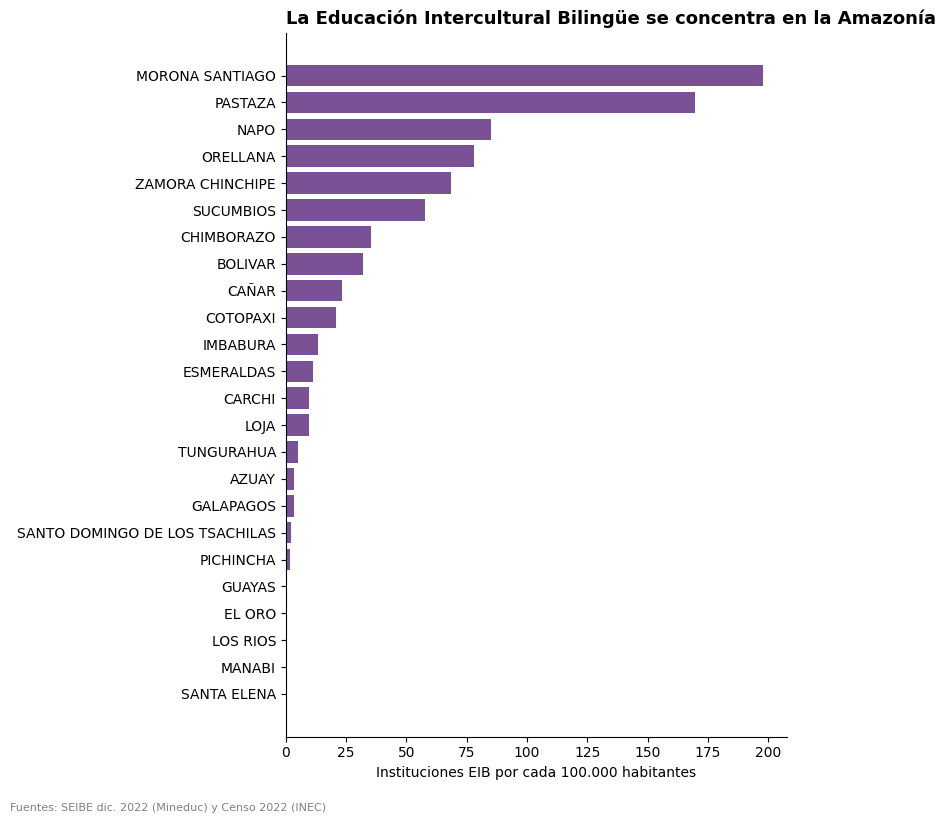

In [10]:
grafico = datos.sort_values("Instituciones por 100 mil hab.")

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(grafico["Provincia"], grafico["Instituciones por 100 mil hab."], color="#7a5195")
ax.set_title("La Educación Intercultural Bilingüe se concentra en la Amazonía",
             loc="left", fontsize=13, fontweight="bold")
ax.set_xlabel("Instituciones EIB por cada 100.000 habitantes")
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.01, -0.02, "Fuentes: SEIBE dic. 2022 (Mineduc) y Censo 2022 (INEC)", fontsize=8, color="gray")
plt.tight_layout()
plt.show()


## 5. Del análisis a la historia (20 min)

Ya tenemos tablas y un gráfico. Pero **un análisis no termina en el código: termina cuando alguien más lo entiende.** Para eso, organizamos lo que hicimos como una historia.

### El arco de una historia con datos

| Momento | Pregunta que responde | En nuestro caso |
|---|---|---|
| **1. Contexto** | ¿Por qué debería importarme? | La EIB es un derecho de pueblos y nacionalidades. ¿Llega a donde se necesita? |
| **2. Pregunta** | ¿Qué queríamos saber? | ¿Dónde está más presente, considerando la población? |
| **3. Hallazgo** | ¿Qué encontramos? | Se concentra en la Amazonía: Morona Santiago y Pastaza encabezan. |
| **4. Evidencia** | ¿Cómo lo sabemos? | El gráfico, y cómo construimos el indicador. |
| **5. Matiz** | ¿Qué no muestran los datos? | Dividimos para la población total, no para la población indígena. |
| **6. ¿Y entonces?** | ¿Qué debería pasar ahora? | Qué otra pregunta o dato haría falta. |

 Los pasos 1 a 4 son lo que solemos presentar. **El 5 y el 6 son los que hacen que una historia sea honesta y útil.**

### Tres pistas para el matiz (elijan una)

- **El denominador.** Pichincha tiene 57 instituciones, pero muy pocas por habitante. ¿Qué cambiaría si comparamos con la población que se autoidentifica como indígena, y no con la población total?
- **Las ausencias.** Santa Elena tiene 0 y Guayas 11. ¿Significa que no hay población indígena ni necesidad de EIB? ¿Qué pasa con quienes migraron a las ciudades?
- **El momento.** La Costa llevaba 8 meses de clases y la Sierra 4 cuando se tomaron los datos. ¿Comparamos lo mismo?

### Trabajo en grupo: su historia en 3 diapositivas

Completen la celda de abajo (doble clic para editar). Es el guion de una presentación de **1 minuto**.

## Nuestra historia · Grupo: ________

### Diapositiva 1 · ¿Por qué importa?
**Contexto y pregunta (2 frases):**
________

### Diapositiva 2 · ¿Qué encontramos?
**Titular (una frase que diga el hallazgo):**
________

**Evidencia:** el gráfico de la sección 4. Lo construimos uniendo SEIBE con el Censo 2022 y calculando instituciones por cada 100 mil habitantes.

### Diapositiva 3 · ¿Qué no sabemos todavía?
**Matiz (lo que los datos no muestran):**
________

**¿Y entonces? (qué dato o pregunta seguiría):**
________

---
**Decisiones que tomamos (para quien quiera repetir el análisis):**
- Asumimos el 31/12/2022 como fecha de corte.
- Igualamos los nombres de provincia (mayúsculas, sin tildes) para poder unir las tablas.
- A Santa Elena le asignamos 0 instituciones.

---
## 6. Cierre (5 min)

Cada grupo presenta su historia en **1 minuto**: titular, gráfico y matiz.

> Ejemplo: *"En proporción a su población, la Amazonía concentra la oferta de Educación Intercultural Bilingüe. Pero medimos frente a la población total: para saber si la EIB llega a quienes la necesitan, haría falta compararla con la población de pueblos y nacionalidades en cada provincia."*

### Lo que nos llevamos

| Del código... | ...a la historia |
|---|---|
| `concat` y `merge` combinan fuentes | Una buena historia suele cruzar datos distintos. |
| `to_datetime` nos dice *cuándo* | Los datos son una foto de un momento. |
| Un indicador por habitante | El denominador cambia el relato. |
| Un título que dice el hallazgo | El lector debe entender el mensaje en 5 segundos. |
| Documentar decisiones y límites | La honestidad sobre lo que no sabemos también es parte del análisis. |

**Para sus proyectos finales:** usen esta misma narrativa (contexto, pregunta, hallazgo, evidencia, matiz, ¿y entonces?) para estructurar su presentación.